# Notebook Description

This notebook uses delivery vehicle telemetry data to create a driver violation detection model (classifier). Unlike regression, which we used to predict customer ratings for delivery trips, classification uses telemetry data to determine if a vehicle on a delivery trip has committed a traffic violation. 

The module's suggested strategy describes a sliding-window, time-series approach (1D-CNN/LSTM on raw timeseries, etc.). This assumes access to raw, sub-trip telemetry, where readings sampled every few seconds throughout a trip.

The dataset, however, is already aggregated at the trip level: each row represents one complete trip, with peak g-force values and event counts summarizing the entire trip rather than a sequence of readings within it. There is no sub-trip time axis left to window over, so sliding-window features and sequence models are not applicable here.

We instead treat this as a **per-trip classification problem**, by using the aggregated features already available (peak g-forces, speed, distance, etc.) to predict whether a violation occurred during the trip, via tree-based classifiers.

# Import

### Modules

In [17]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE 
from xgboost import XGBClassifier

### Data

In [18]:
driver_telemetry = pd.read_csv('../data/preprocessed/telemetry_ratings_preprocessed.csv')

In [19]:
driver_telemetry.head(3)

,Unnamed: 0,trip_id,driver_id,timestamp,max_speed_kmh,avg_speed_kmh,throttle_pct,max_steering_rate_deg_per_s,peak_fwd_x_g,peak_rear_x_g,...,traffic_condition,weather_condition,trip_duration_min,peak_long_g,peak_lat_g,delivery_dayofweek,time_of_day,rating,late_delivery_flag,rating_category
0,0,TRP-100-001,DRV100395,2026-05-19 13:05:21,27.382,20.275,47.438,139.923,0.158,0.360,...,Light,Clear,16.15,0.360,0.230,Tuesday,Noon/Early Afternoon,4.390375,1,Excellent
1,1,TRP-100-002,DRV100381,2026-04-21 16:40:06,63.910,47.545,70.517,191.011,0.411,0.460,...,Moderate,Clear,103.25,0.460,0.346,Tuesday,Late Afternoon/Evening,4.015978,1,Good
2,2,TRP-100-003,DRV100508,2026-03-07 09:03:45,47.191,34.784,50.944,183.156,0.484,0.394,...,Moderate,Clear,189.15,0.484,0.320,Saturday,Morning,3.998266,0,Good


### Target Features
Our data has an `event_code` column which already appears to be a good target feature to use. The problem with this, however, is the *MULTI* class label. Having a class named as such is quite vague, since our model won't have any way to inform us what these multiple violations are. With this, we can use the *_count* columns (hard_brake, overspeed, swerving) to create our target features, and simply exclude the count and event code features to prevent data leakage. 

And since an observation can have more than one type of violation per trip (as implied by *MULTI*), we should build our model such that it is able to perform **multi-label** classification. 

In [20]:
driver_telemetry['hard_brake_flag'] = (driver_telemetry['hard_brake_count'] > 0).astype(int)
driver_telemetry['overspeed_flag'] = (driver_telemetry['overspeed_count'] > 0).astype(int)
driver_telemetry['swerving_flag'] = (driver_telemetry['swerving_count'] > 0).astype(int)

In [21]:
driver_telemetry.to_csv('../data/preprocessed/telemetry_ratings_preprocessed.csv')

Checking the proportion of each class is also a very important step when performing classification. Clearly, from the subset of our data with violation flags, it appears that trips with overspeeding violations make up the least of the subset. To prevent misleading metrics and misrepresenting the minority class (overspeeding_flag, in this case), we need to apply techniques such as resampling, class weight adjustment, etc. 

In [22]:
cols = ['hard_brake_flag','overspeed_flag','swerving_flag']

total = driver_telemetry[
    (driver_telemetry['hard_brake_flag'] == 0) &
    (driver_telemetry['overspeed_flag'] == 0) &
    (driver_telemetry['swerving_flag'] == 0)
]

for col in cols:
    pct = (len(driver_telemetry[driver_telemetry[col] == 1]) / len(total)) * 100
    print(f"{col} proportion:   {pct:.2f}%")

hard_brake_flag proportion:   39.93%
overspeed_flag proportion:   17.25%
swerving_flag proportion:   37.18%


Although tree-based models are non-parametric, unlike linear models, it is still good practice to examine the spread and distribution shape of the data to be used for training. Most of the time, outliers and inconsistencies would have been already handled during the EDA step. In our case, the extremes and multimodal characteristics of our data here, have important meaning. 

Anyways, we still visualize the histograms as another safety check before performing the split. 

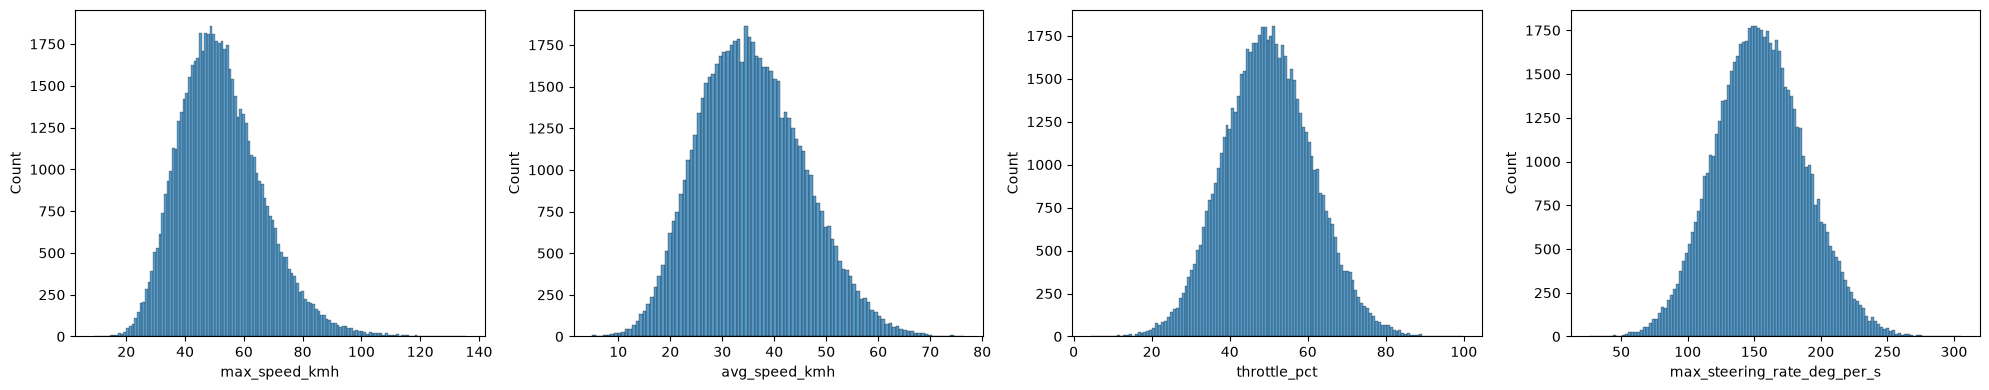

In [23]:
speed_and_input = [
    'max_speed_kmh',
    'avg_speed_kmh',
    'throttle_pct',
    'max_steering_rate_deg_per_s'
]

fig, ax = plt.subplots(1, 4, figsize=(20, 4))

for i, col in enumerate(speed_and_input):
    sns.histplot(
        data=driver_telemetry,
        x=col,
        ax=ax[i]
    )

plt.tight_layout()
plt.show()

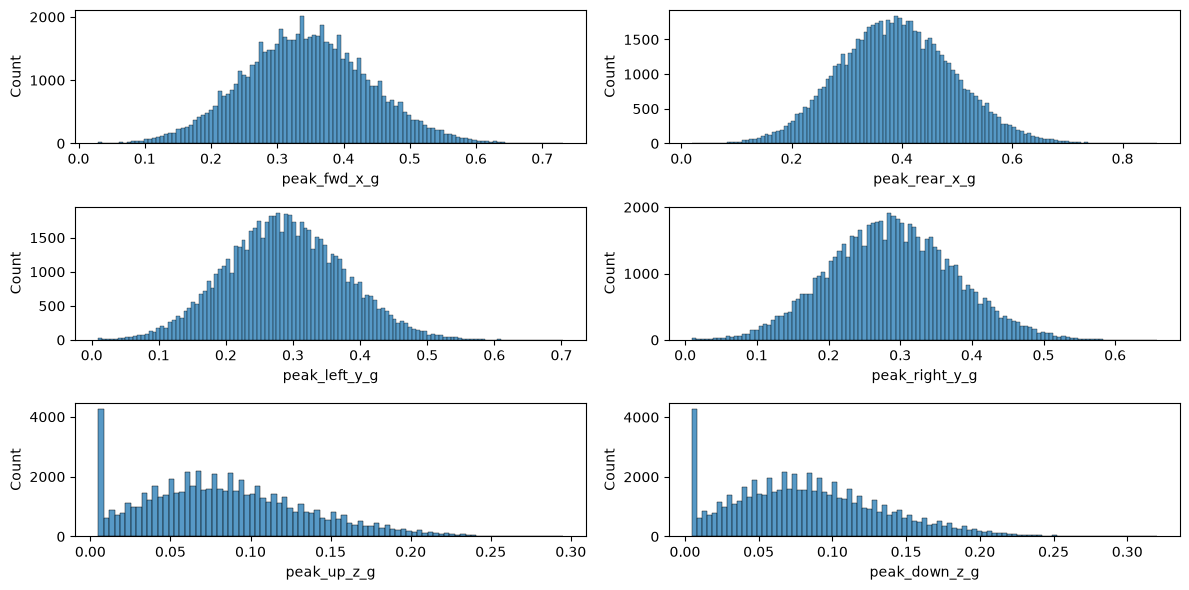

In [24]:
g_forces = [
    'peak_fwd_x_g','peak_rear_x_g',
    'peak_left_y_g','peak_right_y_g',
    'peak_up_z_g','peak_down_z_g'
]

fig, ax = plt.subplots(3, 2, figsize=(12,6))

row = 0
col = 0

for g in g_forces:
    if col > 1:
        col = 0
        row += 1
    
    sns.histplot(
        data=driver_telemetry,
        x=g,
        ax=ax[row,col]
    )
    
    col += 1

plt.tight_layout()
plt.show()   

### Feature Selection

Since tree models are robust to multicollinearity, we can include features that we have excluded from our linear model's training set during the regression task. Maximum and average speed were added, as well as the individual g-force components (in x, y, and z) instead of the peak force for each direction. Categorical columns, such as traffic and weather condition,  were excluded to avoid diluting signal from features directly tied to driver handling. 

In [25]:
feats = [
    'max_speed_kmh', 'avg_speed_kmh',
    'throttle_pct',
    'max_steering_rate_deg_per_s',
    'peak_fwd_x_g','peak_rear_x_g',
    'peak_left_y_g','peak_right_y_g',
    'peak_up_z_g','peak_down_z_g',
    'distance_tr_km','trip_duration_min'
]

targets = ['hard_brake_flag','overspeed_flag','swerving_flag']


X = driver_telemetry[feats]
y = driver_telemetry[targets]

### Split

Like before, we perform a 70/30 split on our dataset. 

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

### Pipeline

For each label in our multi-label feature set, we will have to create one classifier model. One XGBClassifier can technically perform multi-label classification but the problem is that the minority class in our data would be misrepresented as they would all share the same weight (via params. such as `scale_pos_weight`). 

we use a technique known as Synthetic Minority Oversampling Technique (SMOTE) to generate synthetic minority-class examples during training, giving the model more balanced exposure to both violation and non-violation cases. Most importantly, SMOTE is applied inside the pipeline so it only runs on each fold's training slice during cross-validation but not on the validation or test data, which would leak synthetic examples into evaluation and inflate scores.

Stratified K-Fold cross-validation is used alongside SMOTE to get a more robust performance estimate than a single train/test split alone. Stratification ensures each fold preserves the original class proportions of the target flag, which matters especially for the more imbalanced labels. The final model is then refit on the full training set and evaluated once on the held-out test set.

In [27]:
models = {}
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for target in targets:

    pipeline = ImbPipeline(
        steps=[
            ('smote', SMOTE(random_state=42)),
            ('classifier', XGBClassifier(objective='binary:logistic', random_state=42))
        ]
    )

    cv_score = cross_val_score(pipeline, X_train, y_train[target], cv=cv, scoring='f1')
    print(f"{target} CV F1: {cv_score.mean():.4f} (+/- {cv_score.std():.4f})")

    pipeline.fit(X_train, y_train[target])
    models[target] = pipeline

    y_pred = pipeline.predict(X_test)
    results[target] = classification_report(y_test[target], y_pred, output_dict=True)

hard_brake_flag CV F1: 0.6087 (+/- 0.0107)
overspeed_flag CV F1: 0.4812 (+/- 0.0078)
swerving_flag CV F1: 0.5966 (+/- 0.0075)


### Feature Importance

We summarize the classification results for the positive class (violation occurred) across all three flags in a single table. We focus on the positive class (`'1'`) since that is the class we are actually trying to detect. 

In [28]:
res_frame = pd.DataFrame(
    {flag: report['1'] for flag, report in results.items()}
).T

res_frame

,precision,recall,f1-score,support
hard_brake_flag,0.576551,0.667497,0.618699,4818.0
overspeed_flag,0.386441,0.678235,0.492352,2017.0
swerving_flag,0.561509,0.640714,0.598503,4367.0


All three violation flags achieve positive-class F1 scores in the 0.49–0.62 range using purely telemetry-based features. `hard_brake_flag` and `swerving_flag` perform comparably with F1 scores 0.62 and 0.60 respectively, while `overspeed_flag` is the weakest (F1 0.49), consistent with it having the most severe class imbalance and the most easily diluted trip-level signal. Recall is the stronger side of the precision/recall pair for all three flags, meaning the models lean toward catching more true violations at the cost of some false positives, which is a reasonable operating point for a violation-detection task where missing a real event is generally worse than a false alarm.

In [29]:
for target in targets:
    classifier = models[target].named_steps['classifier']
    feature_names = X_train.columns
    
    top5 = pd.Series(classifier.feature_importances_, index=feature_names).sort_values(ascending=False).head(5)
    print(f"--- {target} ---")
    print(top5, "\n")

--- hard_brake_flag ---
peak_rear_x_g     0.524340
peak_up_z_g       0.083640
peak_down_z_g     0.071305
peak_left_y_g     0.040055
peak_right_y_g    0.039082
dtype: float32 

--- overspeed_flag ---
max_speed_kmh     0.498195
distance_tr_km    0.120273
peak_up_z_g       0.065936
peak_down_z_g     0.061655
peak_rear_x_g     0.033728
dtype: float32 

--- swerving_flag ---
max_steering_rate_deg_per_s    0.381896
peak_right_y_g                 0.101696
peak_left_y_g                  0.099543
peak_up_z_g                    0.090896
peak_down_z_g                  0.082841
dtype: float32 



Feature importances show us which predictors contribute most to predictions.

`peak_rear_x_g` dominates hard braking (0.52), as rear-axis deceleration force is the most direct sensor signature of a hard brake event. `max_speed_kmh` dominates overspeeding (0.50) which is the most direct and expected predictor of a speed violation. `max_steering_rate_deg_per_s` dominates swerving (0.38), supported by lateral g-force columns (`peak_right_y_g`, `peak_left_y_g`) as the next most important features. Both of which are physically consistent with sharp lateral maneuvers. 

The vertical g-force columns (`peak_up_z_g`, `peak_down_z_g`) appear consistently across all three models as secondary features, likely capturing road surface roughness or elevation changes that co-occur with aggressive driving contexts. 

Overall, the importance rankings align well with physical intuition, which suggest that the models are learning genuine telemetry signal rather than spurious correlations.

#### Saving the Models

In [30]:
import joblib

joblib.dump(models['hard_brake_flag'].named_steps['classifier'], '../models/xgb_hard_brake.joblib')
joblib.dump(models['swerving_flag'].named_steps['classifier'], '../models/xgb_swerve.joblib')
joblib.dump(models['overspeed_flag'].named_steps['classifier'], '../models/xgb_overspeed.joblib')

['../models/xgb_overspeed.joblib']